# Logistic Regression for Crime Hotspot Prediction

Uses feature-engineered data from `data/feature_engineering/`:
- X_train.csv, X_test.csv: features (location ratios, crime type ratios, district dummies)
- y_train.csv, y_test.csv: binary target 'hotspot' (0/1)

## 1. Setup and Data Loading

Import libraries and load train/test splits from `data/feature_engineering/`.

In [3]:
# --- Imports ---
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


# --- Config ---
FEATURE_DIR = Path("../data/feature_engineering")  # Path to preprocessed train/test splits
RANDOM_STATE = 42  # For reproducibility

# --- Load data ---
# X: features (location ratios, crime type ratios, district one-hot encodings)
# y: binary target (0=non-hotspot, 1=hotspot)
X_train = pd.read_csv(FEATURE_DIR / "X_train.csv")
X_test = pd.read_csv(FEATURE_DIR / "X_test.csv")
y_train = pd.read_csv(FEATURE_DIR / "y_train.csv").squeeze()  # Convert to 1D Series
y_test = pd.read_csv(FEATURE_DIR / "y_test.csv").squeeze()

print(f"Train: X {X_train.shape}, y {y_train.shape}")
print(f"Test:  X {X_test.shape}, y {y_test.shape}")
X_train.head()

Train: X (539, 35), y (539,)
Test:  X (77, 35), y (77,)


,lat_mean,lon_mean,commercial_ratio,institution_ratio,other_ratio,public_ratio,residential_ratio,theft_ratio,battery_ratio,criminal_damage_ratio,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,0.999955,0.613458,0.024346,0.0,0.353061,0.305898,0.316696,0.275542,0.188449,0.116023,...,0,0,0,0,0,0,0,0,1,0
1,0.969214,0.549667,0.020002,0.0,0.322624,0.327702,0.329671,0.232874,0.173386,0.138460,...,0,0,0,0,0,0,0,0,1,0
2,0.873924,0.652839,0.028901,0.0,0.396414,0.305990,0.268695,0.264975,0.190195,0.088611,...,0,0,0,0,0,1,0,0,0,0
3,0.890765,0.562563,0.026954,0.0,0.424438,0.288949,0.259659,0.286433,0.154897,0.119497,...,0,0,0,0,0,0,1,0,0,0
4,0.820561,0.577708,0.024283,0.0,0.447633,0.302674,0.225411,0.361050,0.090753,0.111602,...,0,0,0,0,0,1,0,0,0,0


## 2. Train Model

Fit logistic regression with `class_weight='balanced'` to handle imbalanced hotspot/non-hotspot classes.

In [4]:
# --- Model config ---
# solver='lbfgs': robust optimizer for small/medium datasets
# class_weight='balanced': upweights minority class (hotspot) to handle imbalance
model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
)

# --- Train and predict ---
model.fit(X_train, y_train)
y_pred = model.predict(X_test)  # Binary predictions (0 or 1)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (hotspot)

print("Training complete.")

Training complete.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linea

## 3. Evaluation

Compute accuracy, precision, recall, F1, ROC-AUC, and per-class metrics on the test set.

In [5]:
# --- Metrics ---
# Accuracy: overall correct predictions
# Precision: of predicted hotspots, how many are true hotspots
# Recall: of true hotspots, how many we correctly identified
# F1: harmonic mean of precision and recall
# ROC-AUC: area under ROC curve; measures ranking quality (0.5=random, 1=perfect)
print("Test Set Results:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}" if len(np.unique(y_test)) > 1 else "ROC-AUC: N/A")

# Per-class precision, recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-hotspot", "Hotspot"]))

Test Set Results:
Accuracy : 0.8312
Precision: 0.6207
Recall   : 0.9000
F1-Score : 0.7347
ROC-AUC  : 0.9272

Classification Report:
              precision    recall  f1-score   support

 Non-hotspot       0.96      0.81      0.88        57
     Hotspot       0.62      0.90      0.73        20

    accuracy                           0.83        77
   macro avg       0.79      0.85      0.81        77
weighted avg       0.87      0.83      0.84        77



## 4. Confusion Matrix (Visual)

Visualize predicted vs actual labels in a 2×2 matrix.

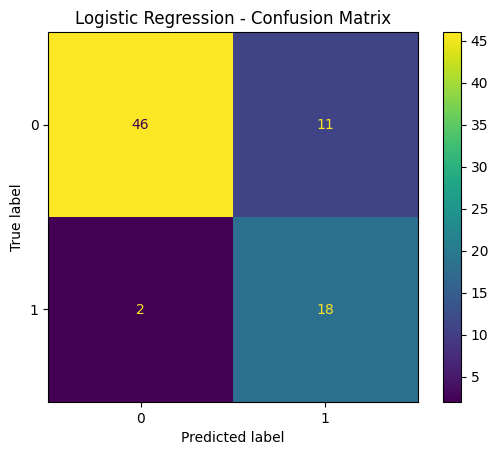

In [6]:
# --- Confusion matrix visualization ---
# Rows: actual class | Columns: predicted class
# Top-left: True Negatives | Top-right: False Positives
# Bottom-left: False Negatives | Bottom-right: True Positives
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 5. Cross-Validation

5-fold stratified CV to estimate model stability and generalization (ROC-AUC).

In [7]:
# --- Cross-validation ---
# StratifiedKFold: preserves class ratio in each fold (important for imbalanced data)
# cross_val_score: fits model on train folds, evaluates on holdout fold; reports mean ± 2*std
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"5-Fold CV ROC-AUC: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

5-Fold CV ROC-AUC: 0.9150 (+/- 0.0446)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_linea

## 6. ROC Curve

Plot TPR vs FPR; area under curve indicates ranking quality.

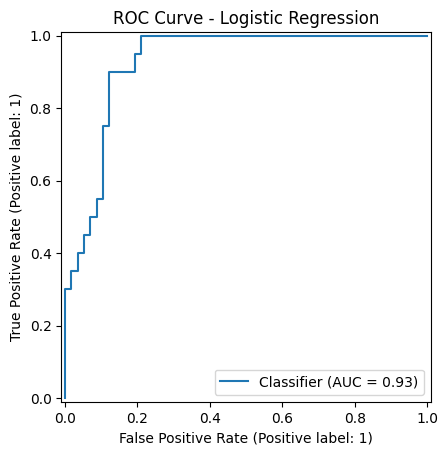

In [8]:
# --- ROC curve ---
# Plots True Positive Rate vs False Positive Rate at various thresholds
# Area under curve (AUC) = probability that model ranks a random positive above a random negative
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

## 7. Feature Coefficients (Importance)

Coefficients show how each feature affects P(hotspot); positive = increases, negative = decreases.

Top 5 positive (increase hotspot probability):


,feature,coefficient
18,district_6,2.262373
19,district_7,2.213783
26,district_15,1.877177
23,district_11,1.422122
24,district_12,1.396323


Top 5 negative (decrease hotspot probability):


,feature,coefficient
16,district_4,-1.920429
32,district_22,-1.943134
21,district_9,-1.961432
27,district_16,-2.089862
14,district_2,-2.512229


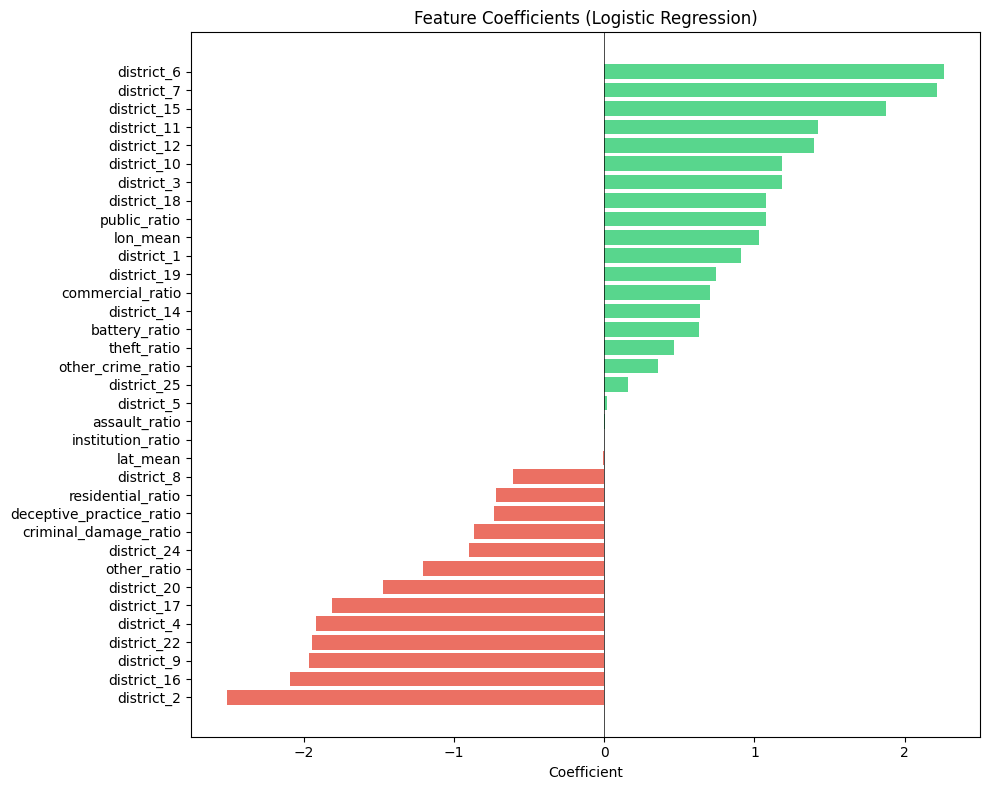

In [9]:
# --- Feature coefficients (interpretability) ---
# Positive coef: higher feature value -> higher P(hotspot)
# Negative coef: higher feature value -> lower P(hotspot)
# Magnitude: strength of effect (on log-odds scale)
coef_df = pd.DataFrame({"feature": X_train.columns, "coefficient": model.coef_[0]}).sort_values("coefficient", ascending=False)

print("Top 5 positive (increase hotspot probability):")
display(coef_df.head())

print("Top 5 negative (decrease hotspot probability):")
display(coef_df.tail())

# --- Bar chart: coefficient magnitude and direction ---
# Green: positive (promotes hotspot) | Red: negative (suppresses hotspot)
fig, ax = plt.subplots(figsize=(10, 8))
coef_sorted = coef_df.sort_values("coefficient", ascending=True)
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in coef_sorted["coefficient"]]
ax.barh(coef_sorted["feature"], coef_sorted["coefficient"], color=colors, alpha=0.8)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient")
ax.set_title("Feature Coefficients (Logistic Regression)")
plt.tight_layout()
plt.show()

In [12]:
import os
import joblib

os.makedirs('../src/models', exist_ok=True)

joblib.dump(model, '../src/models/lr_c.pkl')

print('Model saved to src/models/lr_c.pkl')

Model saved to src/models/lr_c.pkl
